# Lecture 36. 위상 정렬

## 0. 목차

1. 위상 정렬
2. 진입차수와 진출차수
3. 위상 정렬 알고리즘
4. 위상 정렬 동작 예시
5. 위상 정렬 특징
6. 위상 정렬 알고리즘: 소스코드
7. 위상 정렬 알고리즘 성능 분석
8. 피드백
9. 정리 및 회고


## 1. 위상 정렬

- 위상 정렬이란 사이클이 없는 방향 그래프(DAG)의 모든 노드를 방향성에 거스르지 않도록 순서대로 나열한 것을 의미한다.
- 예) 선수솨목을 고려한 학습 순서 설정

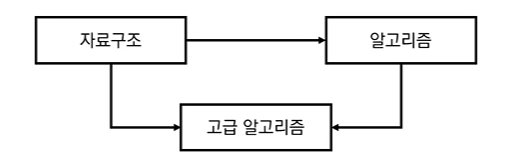

- 위 세 과목을 모두 듣기 위한 적절한 학습 순서는 다음과 같다.
    - 자료구조 - 알고리즘 - 고급 알고리즘

## 2. 진입차수와 진출차수

위상 정렬 다루기 전에 그래프 관련 알고리즘에서 다루는 개념인 진입차수와 진출차수에 대한 개념을 알아야 한다.

- 집입차수(Indegree) : 특정한 노드로 들어오는 간선의 개수
- 진출차수(Outdegree) : 특정한 노드에서 나가는 간선의 개수

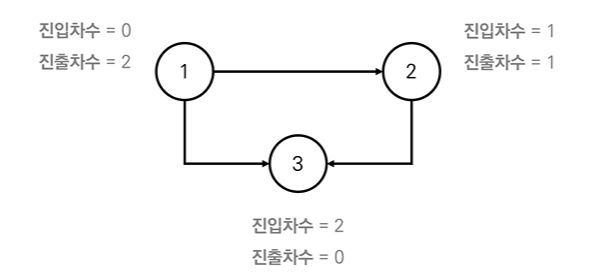

## 3. 위상 정렬 알고리즘

위상 정렬 알고리즘은 DFS로 구현할 수 있고 큐로도 구현할 수 있다. 

- 큐를 이용하는 위상 정렬 알고리즘의 동작 과정은 다음과 같다.
1. 진입차수가 0인 모든 노드를 큐에 넣는다.
2. 큐가 빌 때까지 다음의 과정을 반복한다.
    1) 큐에서 원소를 꺼내 해당 노드에서 나가는 간선을 그래프에서 제거한다.
    2) 새롭게 진입차수가 0이 된 노드를 큐에 넣는다.

결과적으로 각 노드가 큐에 들어온 순서가 위상 정렬을 수행한 결과와 같다.

## 4. 위상 정렬 동작 예시

- 위상 정렬을 수행할 그래프를 준비한다.
    - 이때 그래프는 사이클이 없는 방향 그래프(DAG)여야 한다.
    - 사이클이 존재한다면 진입차수가 적어도 1이상이므로 시작 불가능함.

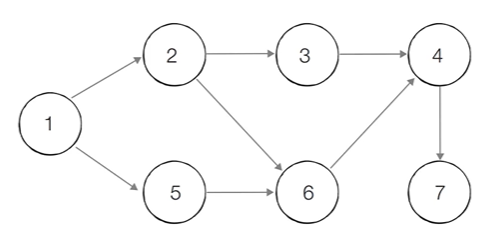

[초기 단계] 초기 단꼐에서는 진입차수가 0인 모든 노드를 큐에 넣는다.
    - 처음에는 노드 1이 큐에 들어간다.

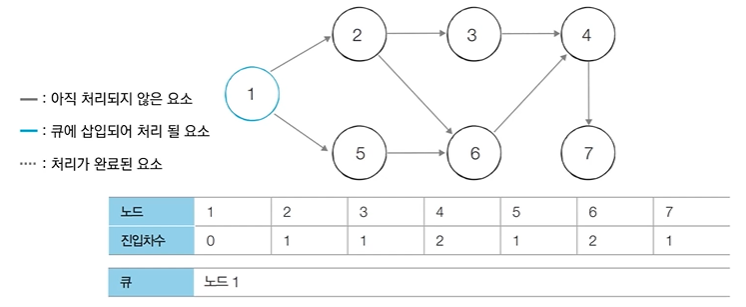

[Step 1] 큐에서 노드 1을 꺼낸 뒤에 노드 1에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드들을 큐에 삽입한다.

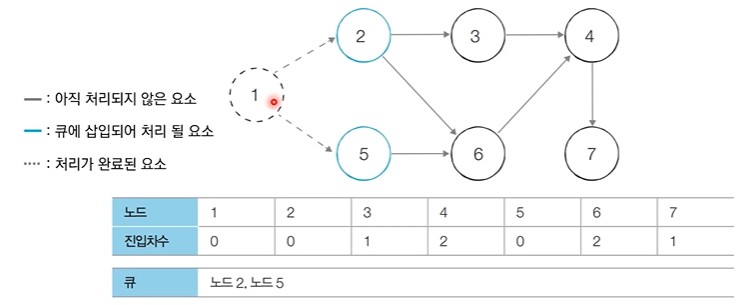

[Step 2] 큐에서 노드 2를 꺼낸 뒤에 노드 2에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드들을 큐에 삽입한다.
    - 큐에 넣는 순서는 여기서는 작은 수를 먼저 넣는 것으로 고정한다.


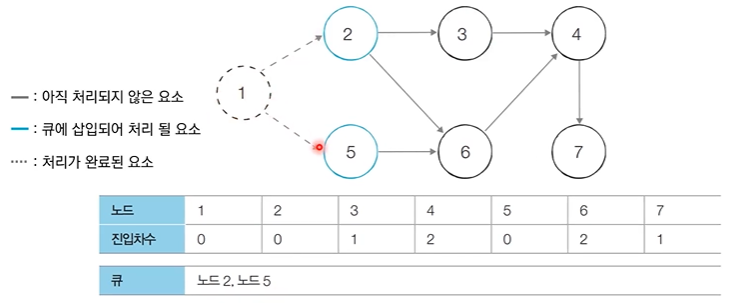

[Step 3] 큐에서 노드 5를 꺼낸 뒤에 노드 5에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드들을 큐에 삽입한다.

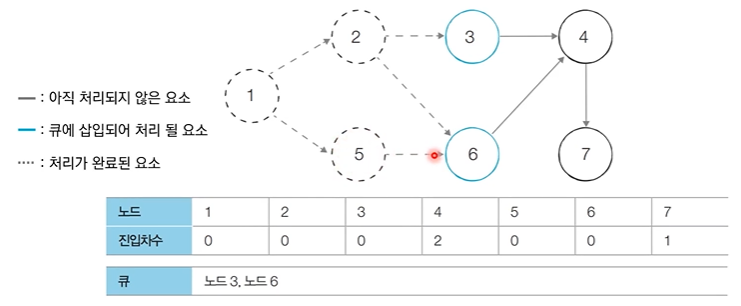

[Step 4] 큐에서 노드 3을 꺼낸 뒤에 노드 3에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드가 없으므로 그냥 넘어간다.

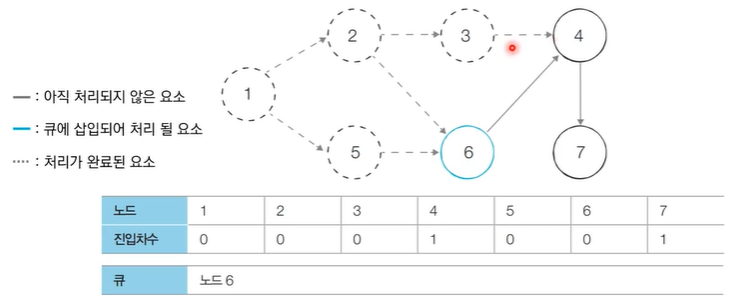

[Step 5] 큐에서 노드 6를 꺼낸 뒤에 노드 6에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드들을 큐에 삽입한다.

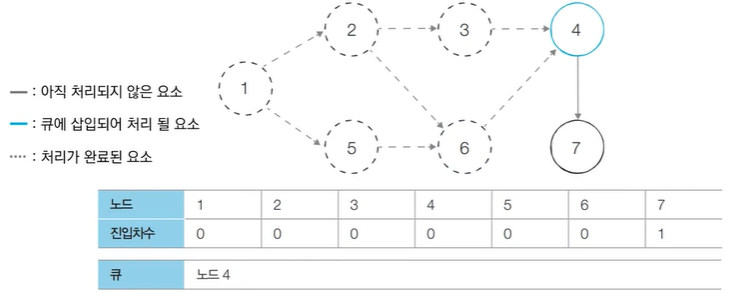

[Step 6] 큐에서 노드 4를 꺼낸 뒤에 노드 4에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드들을 큐에 삽입한다.

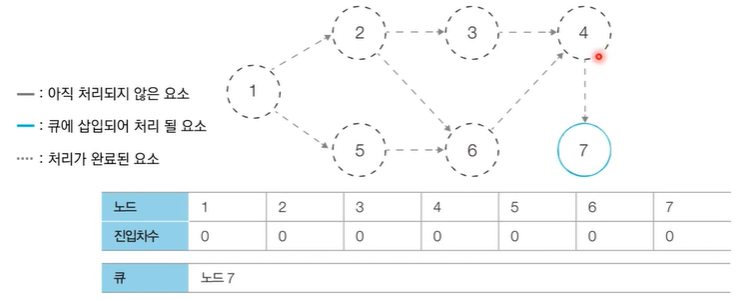

[Step 7] 큐에서 노드 7을 꺼낸 뒤에 노드 7에서 나가는 간선을 제거한다.
    - 새롭게 진입차수가 0이 된 노드가 없으므로 그냥 넘어간다.

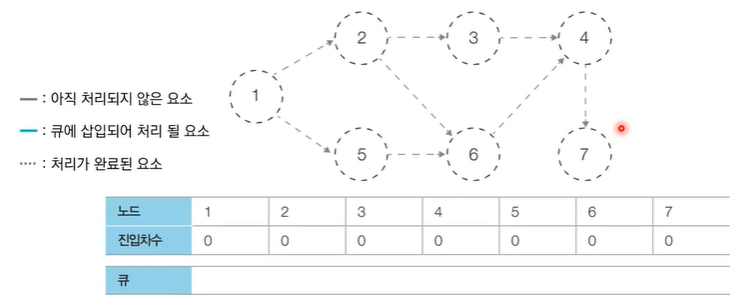

[위상 정렬 결과]
    - 큐에 삽입된 전체 노드 순사: 1 -> 2 -> 5 -> 3 -> 6 -> 4 -> 7

## 5. 위상 정렬 특징

- 위상 정렬은 DAG에 대해서만 수행할 수 있다.
    - DAG(Direct Acyclic Graph) : 순환하지 않는 방향 그래프
- 위상 정렬에서는 여러 가지 답이 존재할 수 있다.
    - 한 단계에서 큐에 새롭게 들어가는 원소가 2개 이상인 경우가 있다면 여러 가지 답이 존재한다.
- 모든 원소를 방문하기 전에 큐가 빈다면 사이클이 존재한다고 판단할 수 있다.
    - 사이클에 포함된 원소 중에서 어떠한 원소도 큐에 들어가지 못한다.
- 스택을 활용한 DFS를 이용해 위상 정렬을 수행할 수도 있다.

## 6. 위상 정렬 알고리즘: 소스코드

### 구현 

필요한 것 : 노드, 간선 정보(집입차수, 진출차수, from to)

구현 계획
1. 노드 개수 v , 간선 개수 e
2. 노드 마다 집입차수, 진출 어디로 가는지
3. 


In [ ]:
from collections import deque

INF = int(1e9)
# 노드 간선 
v, e= map(int, input().split())

node = [[] for _ in range(v+1)]
inputdegree = [0] * (v+1)
inputdegree[0] = INF
# 노드 진출차수 및 간선 정보 입력
for _ in range(e):
    inout , output = map(int, input().split())
    node[input].append(output)
    inputdegree[input] += 1

q = []
result = []

for _ in range(v):
    for i in range(1, v+1):
        if inputdegree[i] == 0:
            deque.appendleft(q, i)
            result.append(i)
            inputdegree[i] = INF

### 실패 원인

1. 이론적으로 어떻게 해야 하는지 머리로는 알지만, 어떻게 구현해야 할지 모르겠음.
2. 아직 코드 구현하는 것이 익숙하지 않은 것으로 보임.

### 정답

```python
from collections import deque

# 노드의 개수와 간선의 개수를 입력 받기
v, e = map(int, input().split())
# 모든 노드에 대한 진입차수는 0으로 초기화
indegree = [0] * (v+1)
# 각 노드에 연결된 간선 정보를 담기 위한 연결 리스트 초기화
graph = [[] for i in range(v+1)]

# 방향 그래프의 모든 간선 정보를 입력 받기
for _ in range(e):
    a, b = map(int, input().split())
    graph[a].append(b) # 정점 A에서 B로 이동 가능
    # 진입 차수를 1 증가
    indegree[b] += 1

'''
입력 예시
7 8
1 2
1 5
2 3
2 6
3 4
4 7
5 6
6 4

출력 예시
1 2 5 3 6 4 7
'''

# 위상 정렬 함수
def topology_sort():
    result = [] # 알고리즘 수행 결과를 담을 리스트
    q = deque() # 큐 기능을 위한 deque 라이브러리 사용
    # 처음 시작할 때는 진입차수가 0인 노드를 큐에 삽입
    for i in range(1, v+1):
        if indegree[i] == 0:
            q.append(i)
    # 큐가 빌 때까지 반복
    while q:
        # 큐에서 원소 꺼내기
        now = q.popleft()
        result.append(now)
        # 해당 원소와 연결된 노드들의 진입차수에서 1 빼기
        for i in graph[now]:
            indegree[i] -= 1
            # 새롭게 진입차수가 0이 되는 노드를 큐에 삽입
            if indegree[i] == 0:
                q.append(i)
    # 위상 정렬을 수행한 결과 출력
    for i in result:
        print(i, end= ' ')

topology_sort()
```

## 7. 위상 정렬 알고리즘 성능 분석

- 위상 정렬을 위해 차례대로 모든 노드를 확인하며 각 노드에서 나가는 간선을 차례대로 제거해야 한다.
    - 위상 정렬 알고리즘의 시간 복잡도는 $O(V + E)$이다.
    - 노드 각 확인(V)과 나가는 간선 확인(E)하기 때문


## 8. 피드백

### Gemini 이용 부족한 점 피드백

```
위상 정렬(Topological Sort)의 핵심 원리를 직접 구현해 보려고 하셨군요! 처음 배울 때 가장 헷갈리는 부분이 **'진입 차수(Indegree)'의 관리**와 **'큐(Queue)'의 역할**인데, 작성하신 코드에서 몇 가지 중요한 논리적 오류가 보입니다.

작성하신 코드와 답안을 비교하며 어떤 점을 보완하면 좋을지 짚어 드릴게요.

---

## 1. 진입 차수(Indegree)의 개념 오류
위상 정렬에서 **진입 차수**는 '나에게 들어오는 간선의 수'입니다. 즉, "내가 시작하기 위해 먼저 끝나야 하는 작업의 개수"와 같습니다.

* **사용자 코드:** `inputdegree[input] += 1` (출발 노드의 차수를 높임)
* **답안 코드:** `indegree[b] += 1` (도착 노드의 차수를 높임)

> **교정:** `A -> B`로 가는 간선이 있다면, `B`를 하기 위해 `A`가 선행되어야 하므로 **도착지인 `B`의 진입 차수**를 올려야 합니다. 작성하신 코드는 반대로 출발지의 차수를 높이고 있어 논리적으로 '진출 차수'를 계산하고 있습니다.

---

## 2. 큐(Queue)를 활용한 동적 업데이트 부재
위상 정렬의 핵심은 **"진입 차수가 0이 된 노드를 즉시 큐에 넣고, 그 노드와 연결된 간선을 제거하며 연쇄 반응을 일으키는 것"**입니다.

* **사용자 코드:** 중첩 `for`문을 사용하여 매번 전체 노드를 확인합니다. 이는 비효율적일 뿐만 아니라, 특정 노드가 제거되었을 때 그와 연결된 다음 노드의 진입 차수를 줄여주는 로직이 빠져 있습니다.
* **답안 코드:** `while q:`를 통해 큐에서 노드를 하나 꺼낼 때마다, 그와 연결된 노드(`graph[now]`)들의 진입 차수를 `1`씩 줄입니다.



---

## 3. 문법 및 구현상의 디테일
몇 가지 파이썬 문법적인 실수와 비효율적인 부분이 있습니다.

* **변수명 오타:** `node[input].append(output)`에서 `input`은 파이썬 내장 함수 이름입니다. 또한 위에서 `inout`으로 받으셨는데 아래서 `input`으로 쓰셔서 에러가 발생할 수 있습니다.
* **큐 사용법:** `deque.appendleft(q, i)` 보다는 `q.append(i)` (오른쪽 삽입) 후 `q.popleft()` (왼쪽 추출)를 사용하는 것이 일반적입니다. 무엇보다 `q = []`로 선언하면 리스트이므로 `deque` 메서드를 직접 호출하는 방식은 맞지 않습니다. `q = deque()`로 선언해야 합니다.
* **불필요한 INF 사용:** 진입 차수를 관리할 때 이미 처리한 노드를 제외하기 위해 `INF`를 넣으셨는데, 큐를 사용하면 한 번 큐에 들어간 노드는 다시 검사하지 않으므로 이런 처리가 필요 없습니다.

---

## 요약: 어떻게 개선하면 좋을까요?

1.  **방향성 확인:** `a -> b` 간선 입력 시 `indegree[b] += 1`을 기억하세요.
2.  **연쇄 효과 구현:** 노드를 결과 리스트에 넣는 것에 그치지 말고, **"그 노드가 사라졌으니 연결된 다음 노드들의 진입 차수도 1씩 줄어든다"**는 로직을 반드시 넣어야 합니다.
3.  **큐 활용:** `for`문으로 전체를 계속 훑지 말고, `0`이 되는 순간 큐에 '예약'을 걸어두는 방식으로 작성해 보세요.

직접 코드를 짜보신 덕분에 답안 코드를 보셨을 때 "왜 `indegree[i] -= 1`을 하는지" 그 이유를 훨씬 더 깊게 이해하셨을 거예요! 이 부분이 위상 정렬의 알파이자 오메가입니다.

혹시 큐가 비었는데 모든 노드를 방문하지 못하는 상황(사이클 발생)에 대해서도 궁금하신가요?
```

요약
1. 진입 차수 구현을 잘못함. - 도착하는 노드 기준으로 +1 해야 함.
2. 진입 차수 0인 노드 선택해서 큐에 넣고 제거하면서 노드 이동하는 것을 못함
3. 큐 사용방법을 모름.
4. INF, 이중 for문 등.. 비효율적인 동작 과정

### 메모 기반 개선 사항

```
메모를 아주 잘 시작하셨어요! 위상 정렬을 구현하기 위해 필요한 **재료(Data Structure)**는 완벽하게 파악하셨습니다. 하지만 요리로 치면 재료만 준비하고 **조리 순서(Algorithm Flow)**에서 막힌 상태라고 볼 수 있어요.

본인의 메모에서 빠진 **'3번 이후의 과정'**과 로직에서 가장 중요한 **'연쇄 반응'** 부분을 구체적으로 짚어 드릴게요.

---

## 1. 부족했던 핵심 로직: "연쇄 삭제"
위상 정렬은 단순히 진입 차수가 0인 노드를 찾는 게 끝이 아닙니다. **"내가 끝났으니, 나를 기다리던 다음 작업들의 대기 줄을 하나씩 줄여준다"**는 개념이 핵심이에요.

* **메모 보완 (3번 이후):**
    * 3. 진입 차수가 0인 노드를 **큐(Queue)**에 모두 넣는다.
    * 4. 큐가 빌 때까지 다음을 반복한다:
        * 큐에서 노드(A)를 꺼내 결과 리스트에 담는다.
        * **노드 A와 연결된 모든 다음 노드(B, C...)들의 진입 차수를 1씩 감소시킨다.** (간선 제거)
        * 이때 진입 차수가 **새롭게 0이 된 노드**가 있다면 즉시 큐에 넣는다.



---

## 2. '진입'과 '진출'의 활용법 구분
작성하신 계획에서 "집입차수, 진출 어디로 가는지"를 적으셨는데, 이를 실제 코드에서 어떻게 쓸지 명확히 구분해야 합니다.

| 항목 | 용도 | 데이터 구조 |
| :--- | :--- | :--- |
| **진입 차수 (Indegree)** | **"내가 지금 출발할 수 있는가?"**를 판단하는 척도. 0이 되어야 출발 가능. | 리스트/배열 (`[0, 1, 0, ...]`) |
| **진출 정보 (Graph)** | **"내가 끝난 뒤 누구를 호출할 것인가?"**를 알기 위한 정보. | 인접 리스트 (`[ [], [2, 5], [3], ... ]`) |

---

## 3. 왜 '큐(Queue)'가 반드시 필요한가?
사용자님은 처음에 `for`문을 돌려 0인 노드를 찾으려 하셨죠? 그렇게 하면 **실시간으로 0이 되는 노드**를 놓치거나, 이미 처리한 노드를 중복해서 확인해야 하는 번거로움이 생깁니다.

* **효율성:** 큐를 쓰면 "새롭게 진입 차수가 0이 된 노드"만 딱 집어서 처리할 수 있습니다. (시간 복잡도 $O(V + E)$)
* **순서 보장:** 먼저 준비된 작업부터 순차적으로 처리하는 논리적 흐름을 유지해 줍니다.

---

## 💡 요약하자면
사용자님의 메모에 **"간선을 제거하여 다음 노드의 진입 차수를 갱신한다"**는 문장 하나만 추가되어도 구현 능력이 확 올라갈 거예요.

**연습 팁:** 종이에 노드 3~4개를 그려놓고, 손으로 직접 "화살표를 하나 지울 때마다 숫자를 1씩 줄이는 과정"을 시뮬레이션해 보세요. 그 과정이 그대로 코드가 됩니다!

혹시 이 과정을 코드로 옮길 때, `while q:` 내부에서 `for`문을 어떻게 돌려야 할지 감이 오시나요?
```

요약
1. 중요한 로직과 순서를 잘 이해하지 못했음.

## 9. 정리 및 회고

### 순서
1. 위상 정렬
2. 진입차수와 진출차수
3. 위상 정렬 알고리즘
4. 위상 정렬 동작 예시
5. 위상 정렬 특징
6. 위상 정렬 알고리즘: 소스코드
7. 위상 정렬 알고리즘 성능 분석
8. 피드백
9. 정리 및 회고

### 키워드
위상 정렬, 진입차수, 진출차수, 큐, 사이클이 없는 방향 그래프(DAG)

### 회고
1. topology라는 단어가 나와서 반가웠음.
2. 구현하는 방법이 짧아서 바로 할 수 있을 줄 알았는데, 구현에 실패했음.
3. 구현 전에 어떤 방식으로 구현할지 메모를 제대로 하고 구현하는 것이 좋은 것 같음. 그래야 피드백도 잘 받을 수 있음.